# Part 3 — SARIMA Modelling

This notebook fits a seasonal ARIMA (SARIMA) model to weekly German electricity
demand. We search over ARIMA orders using the AIC criterion, inspect the model
residuals to assess adequacy, forecast the two-year test period with confidence
intervals, and compare performance against the seasonal-naive benchmark
established in Part 2.

## Setup

We mount Google Drive (so the dataset persists across runtime restarts), clone
the project repository, and make the `electricity_demand` package importable.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os, shutil, sys

# Clone the repository if the runtime has been reset
if not os.path.exists("/content/electricity-demand-forecasting"):
    !git clone https://github.com/iisratislam/electricity-demand-forecasting.git

%cd /content/electricity-demand-forecasting

# Copy the dataset in from Drive (it is not committed to the repository)
os.makedirs("data/raw", exist_ok=True)
drive_csv = "/content/drive/MyDrive/electricity_data/time_series_60min_singleindex.csv"
target    = "data/raw/time_series_60min_singleindex.csv"
if not os.path.exists(target):
    shutil.copy(drive_csv, target)

# Make the src package importable
sys.path.append("src")
print("Environment ready.")

Cloning into 'electricity-demand-forecasting'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 63 (delta 13), reused 49 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 1.45 MiB | 26.50 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/electricity-demand-forecasting
Environment ready.


## Loading data and recreating the train/test split

We rebuild the weekly mean-load series using the data module written in Part 1,
then apply the same 104-week (two-year) chronological split used for the
benchmarks. Using an identical split ensures every model in this study is
evaluated on exactly the same held-out period.

A chronological split is essential in time-series forecasting: the model must
only ever learn from the past, never from the future it is asked to predict.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_demand.data import load_raw_load, to_weekly_gw

# Rebuild the weekly mean-load series (GW) from the raw hourly data
weekly = to_weekly_gw(load_raw_load("data/raw/time_series_60min_singleindex.csv"))

TEST_WEEKS = 104                      # two-year forecast horizon
train = weekly.iloc[:-TEST_WEEKS]
test  = weekly.iloc[-TEST_WEEKS:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} weeks)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} weeks)")

Train: 2015-01-04 -> 2018-10-07 (197 weeks)
Test : 2018-10-14 -> 2020-10-04 (104 weeks)


## SARIMA order selection using AIC

SARIMA has six parameters: the non-seasonal orders (p, d, q) and the seasonal
orders (P, D, Q) at period s. We search for the best non-seasonal orders over the
ranges specified in the brief — p in [0,6], d in [0,2], q in [0,6] — while holding
the seasonal component fixed at (1, 1, 1, 52).

The seasonal period s = 52 and seasonal differencing D = 1 are justified by the
Part 1 analysis: the ACF showed a clear annual spike at lag 52, while ADF and KPSS
both indicated the *level* of the series was already stationary.

A full joint search over all non-seasonal **and** seasonal orders would require
over a thousand model fits, each computationally expensive at s = 52. We therefore
adopt a **staged search**, a standard and pragmatic approach: first optimise
(p, d, q), then refine the seasonal orders.

**AIC (Akaike Information Criterion)** balances goodness of fit against model
complexity — lower is better, and additional parameters are penalised unless they
genuinely improve the fit.

All modelling logic is written to `src/electricity_demand/models/sarimax.py` so it
can be reused by the pipeline and tests, not only this notebook.

In [ ]:
%%writefile src/electricity_demand/models/sarimax.py
"""
sarimax.py
----------
SARIMA / SARIMAX model fitting, order selection, and forecasting.

Order selection uses the Akaike Information Criterion (AIC), which balances model
fit against complexity. Fits that fail to converge are skipped rather than
raising, so the search is robust across the full parameter grid.

The resumable search variant persists results to disk after every fit, allowing a
long grid search to survive runtime interruptions.
"""

from __future__ import annotations
import itertools
import os
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


def search_sarima_orders_resumable(
    y_train: pd.Series,
    checkpoint_path: str,
    p_range=range(0, 7),
    d_range=range(0, 3),
    q_range=range(0, 7),
    seasonal_order=(1, 1, 1, 52),
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Grid-search non-seasonal (p, d, q) orders by AIC, saving progress after
    every fit.

    Results are appended to a CSV checkpoint file. If the search is interrupted,
    re-running this function skips any combination already recorded, allowing the
    search to resume rather than restart.

    Parameters
    ----------
    y_train : pd.Series
        Training series.
    checkpoint_path : str
        CSV file used to persist results between runs.
    p_range, d_range, q_range : iterable of int
        Candidate values for the AR order, differencing order, and MA order.
    seasonal_order : tuple
        Fixed seasonal order (P, D, Q, s).
    verbose : bool
        If True, print progress for each fit.

    Returns
    -------
    pd.DataFrame
        All results recorded so far, sorted by AIC ascending (best first).
    """
    # Resume from any previously completed fits
    if os.path.exists(checkpoint_path):
        done = pd.read_csv(checkpoint_path)
        completed = {tuple(r) for r in done[["p", "d", "q"]].values}
        if verbose:
            print(f"Resuming: {len(completed)} combinations already completed.\n")
    else:
        completed = set()

    combos = list(itertools.product(p_range, d_range, q_range))
    total = len(combos)

    for i, (p, d, q) in enumerate(combos, start=1):
        if (p, d, q) in completed:
            continue                      # already fitted in an earlier run

        try:
            model = SARIMAX(
                y_train,
                order=(p, d, q),
                seasonal_order=seasonal_order,
                trend="c" if d == 0 else None,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            row = {"p": p, "d": d, "q": q, "aic": fit.aic}

            if verbose:
                print(f"[{i:3d}/{total}] SARIMA({p},{d},{q}) AIC={fit.aic:.2f}")

        except Exception:
            # Non-convergent or invalid parameterisations are skipped
            if verbose:
                print(f"[{i:3d}/{total}] SARIMA({p},{d},{q}) failed - skipped")
            continue

        # Persist immediately so nothing is lost on disconnection
        pd.DataFrame([row]).to_csv(
            checkpoint_path,
            mode="a",
            header=not os.path.exists(checkpoint_path),
            index=False,
        )

    results = pd.read_csv(checkpoint_path)
    return results.sort_values("aic").reset_index(drop=True)


def search_seasonal_orders(
    y_train: pd.Series,
    order: tuple,
    P_range=range(0, 2),
    D_range=range(0, 2),
    Q_range=range(0, 2),
    s: int = 52,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Grid-search seasonal orders (P, D, Q) by AIC, with (p, d, q) held fixed.

    This is the second stage of a staged order-selection procedure: the
    non-seasonal orders are chosen first, then the seasonal structure refined.

    Parameters
    ----------
    y_train : pd.Series
        Training series.
    order : tuple
        Fixed non-seasonal order (p, d, q) from stage one.
    P_range, D_range, Q_range : iterable of int
        Candidate seasonal AR, differencing, and MA orders.
    s : int, default 52
        Seasonal period (52 weeks = one year).
    verbose : bool
        If True, print each fit's AIC.

    Returns
    -------
    pd.DataFrame
        Columns (P, D, Q, aic), sorted by AIC ascending.
    """
    results = []
    combos = list(itertools.product(P_range, D_range, Q_range))

    for i, (P, D, Q) in enumerate(combos, start=1):
        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=(P, D, Q, s),
                trend="c" if order[1] == 0 else None,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            results.append({"P": P, "D": D, "Q": Q, "aic": fit.aic})

            if verbose:
                print(f"[{i}/{len(combos)}] seasonal({P},{D},{Q},{s}) AIC={fit.aic:.2f}")

        except Exception:
            if verbose:
                print(f"[{i}/{len(combos)}] seasonal({P},{D},{Q},{s}) failed - skipped")
            continue

    return pd.DataFrame(results).sort_values("aic").reset_index(drop=True)


def fit_sarimax(y_train: pd.Series, order: tuple, seasonal_order: tuple,
                X_train: pd.DataFrame | None = None):
    """
    Fit a SARIMAX model with the given orders and optional exogenous regressors.

    Parameters
    ----------
    y_train : pd.Series
        Training target series.
    order : tuple
        Non-seasonal order (p, d, q).
    seasonal_order : tuple
        Seasonal order (P, D, Q, s).
    X_train : pd.DataFrame, optional
        Exogenous regressors aligned to y_train (used in Part 4).

    Returns
    -------
    statsmodels results object
        The fitted model.
    """
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        seasonal_order=seasonal_order,
        trend="c" if order[1] == 0 else None,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


def forecast_sarimax(model_fit, horizon: int, index: pd.Index,
                     X_test: pd.DataFrame | None = None, alpha: float = 0.05):
    """
    Produce a forecast with confidence intervals from a fitted SARIMAX model.

    Parameters
    ----------
    model_fit : statsmodels results object
        A fitted SARIMAX model.
    horizon : int
        Number of steps to forecast.
    index : pd.Index
        Datetime index to assign to the forecast.
    X_test : pd.DataFrame, optional
        Exogenous regressors for the forecast period.
    alpha : float, default 0.05
        Significance level; 0.05 gives a 95% confidence interval.

    Returns
    -------
    tuple of (pd.Series, pd.DataFrame)
        (point forecast, confidence interval with lower and upper columns)
    """
    fc = model_fit.get_forecast(steps=horizon, exog=X_test)
    mean = fc.predicted_mean
    conf = fc.conf_int(alpha=alpha)
    mean.index = index
    conf.index = index
    return mean, conf

Overwriting src/electricity_demand/models/sarimax.py


### Running the AIC grid search

We fit all 147 combinations of (p, d, q). The checkpoint file is stored in Google
Drive rather than the local Colab filesystem, so progress survives a runtime
restart. Re-running this cell after an interruption resumes the search from where
it stopped, rather than repeating completed work.

In [5]:
import time
from electricity_demand.models.sarimax import search_sarima_orders_resumable

# Checkpoint lives in Drive so progress survives runtime restarts
CHECKPOINT = "/content/drive/MyDrive/electricity_data/sarima_aic_checkpoint.csv"

start = time.time()

order_results = search_sarima_orders_resumable(
    train,
    checkpoint_path=CHECKPOINT,
    p_range=range(0, 7),      # brief: p = [0, 6]
    d_range=range(0, 3),      # brief: d = [0, 2]
    q_range=range(0, 7),      # brief: q = [0, 6]
    seasonal_order=(1, 1, 1, 52),
    verbose=True,
)

print(f"\nElapsed this run: {(time.time() - start)/60:.1f} minutes")
print(f"Total fits recorded: {len(order_results)}\n")
print("Top 10 models by AIC:")
print(order_results.head(10).to_string(index=False))

Resuming: 147 combinations already completed.


Elapsed this run: 0.0 minutes
Total fits recorded: 147

Top 10 models by AIC:
 p  d  q        aic
 3  1  6 303.363079
 0  1  6 303.370637
 2  0  6 304.187357
 5  0  6 304.880862
 5  1  6 304.933202
 4  0  6 305.299618
 0  0  6 305.674879
 2  1  6 306.670452
 1  0  6 307.674994
 3  0  6 308.027597


### Interpreting the AIC search

Two observations shape our model choice.

**Boundary effect.** All ten best-fitting models have q = 6, the maximum value
permitted by the specified search range. The AIC was therefore still improving as
q increased, suggesting the unconstrained optimum may lie beyond the searched
grid. We note this as a limitation of the prescribed range.

**Parsimony.** The two leading models, SARIMA(3,1,6) and SARIMA(0,1,6), differ in
AIC by only 0.008. Models within a difference of 2 AIC units are conventionally
regarded as statistically indistinguishable (Burnham and Anderson, 2002). We
therefore select SARIMA(0,1,6), which attains the same fit using three fewer
autoregressive parameters. Preferring the simpler of two equivalent models reduces
overfitting risk and improves interpretability.

In [6]:
# Compute delta-AIC relative to the best model to identify statistically
# equivalent candidates. A difference below 2 is the conventional threshold.
order_results["delta_aic"] = order_results["aic"] - order_results["aic"].min()
order_results["n_params"]  = order_results["p"] + order_results["q"]

print("Models statistically equivalent to the best (delta AIC < 2):\n")
print(order_results[order_results["delta_aic"] < 2]
      .sort_values("n_params")
      .to_string(index=False))

Models statistically equivalent to the best (delta AIC < 2):

 p  d  q        aic  delta_aic  n_params
 0  1  6 303.370637   0.007557         6
 2  0  6 304.187357   0.824278         8
 3  1  6 303.363079   0.000000         9
 4  0  6 305.299618   1.936539        10
 5  0  6 304.880862   1.517783        11
 5  1  6 304.933202   1.570123        11


### Stage 2: refining the seasonal orders

With the non-seasonal orders fixed at (0, 1, 6), we now search the seasonal orders
(P, D, Q) with the period fixed at s = 52. Only eight fits are required, avoiding
the thousand-plus a full joint search would demand.

Part 1 evidence suggests D = 1 is appropriate, since the ACF showed strong annual
structure. Including D = 0 in the grid allows this expectation to be tested rather
than merely assumed.

In [7]:
from electricity_demand.models.sarimax import search_seasonal_orders

BEST_ORDER = (0, 1, 6)   # selected by parsimony from stage one

seasonal_results = search_seasonal_orders(
    train,
    order=BEST_ORDER,
    P_range=range(0, 2),
    D_range=range(0, 2),
    Q_range=range(0, 2),
    s=52,
    verbose=True,
)

print("\nSeasonal order search results (sorted by AIC):")
print(seasonal_results.to_string(index=False))

[1/8] seasonal(0,0,0,52) AIC=845.97
[2/8] seasonal(0,0,1,52) AIC=3729.64
[3/8] seasonal(0,1,0,52) AIC=530.59
[4/8] seasonal(0,1,1,52) AIC=302.88
[5/8] seasonal(1,0,0,52) AIC=550.22
[6/8] seasonal(1,0,1,52) AIC=4501.29
[7/8] seasonal(1,1,0,52) AIC=334.81
[8/8] seasonal(1,1,1,52) AIC=303.37

Seasonal order search results (sorted by AIC):
 P  D  Q         aic
 0  1  1  302.882168
 1  1  1  303.370637
 1  1  0  334.812454
 0  1  0  530.593516
 1  0  0  550.215020
 0  0  0  845.969155
 0  0  1 3729.640306
 1  0  1 4501.286074




The seasonal search decisively confirms the Part 1 diagnosis. Every model with
seasonal differencing (D = 1) outperforms every model without it, and the margin
is large: the best D = 0 specification attains AIC 550.2 against 302.9 for the
best D = 1 model. The ACF evidence for annual structure is thus validated by an
independent likelihood-based criterion.

The two worst fits, seasonal (0,0,1) and (1,0,1) with AIC values above 3700, are
those applying a seasonal moving-average term *without* seasonal differencing.
Such specifications attempt to absorb the annual cycle into the error structure
rather than removing it, and are evidently misspecified for this series.

The selected seasonal order is therefore **(0, 1, 1, 52)**, which improves on the
(1, 1, 1, 52) assumption used during stage one (AIC 302.88 against 303.37) while
using one fewer parameter.

**Final AIC-selected model: SARIMA(0, 1, 6)(0, 1, 1) with s = 52.**

In [9]:
import os
os.makedirs("outputs/metrics", exist_ok=True)

# Persist both search stages as evidence for the report
order_results.to_csv("outputs/metrics/sarima_aic_search.csv", index=False)
seasonal_results.to_csv("outputs/metrics/sarima_seasonal_search.csv", index=False)

# The final selected specification
FINAL_ORDER          = (0, 1, 6)
FINAL_SEASONAL_ORDER = (0, 1, 1, 52)

print(f"Final model: SARIMA{FINAL_ORDER}{FINAL_SEASONAL_ORDER}")
print(f"AIC: {seasonal_results.iloc[0]['aic']:.3f}")


Final model: SARIMA(0, 1, 6)(0, 1, 1, 52)
AIC: 302.882


## Fitting the AIC-selected model

We fit SARIMA(0,1,6)(0,1,1) with s = 52 to the training data and inspect the
parameter estimates. The summary reports coefficient values, standard errors, and
significance tests for each term, allowing us to assess whether the selected
parameters are genuinely identifiable from the data.

In [10]:
from electricity_demand.models.sarimax import fit_sarimax

sarima_fit = fit_sarimax(
    y_train=train,
    order=FINAL_ORDER,
    seasonal_order=FINAL_SEASONAL_ORDER,
)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(0, 1, 6)x(0, 1, [1], 52)   Log Likelihood                -143.441
Date:                              Fri, 10 Jul 2026   AIC                            302.882
Time:                                      16:11:07   BIC                            322.423
Sample:                                  01-04-2015   HQIC                           310.742
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5748    174.111     -0.003      0.997    -341.827     340.677
ma.L2         -0.38

### Diagnosing over-parameterisation

The coefficient table reveals a serious problem. Every non-seasonal MA coefficient
is statistically insignificant, with standard errors up to two orders of magnitude
larger than the estimates themselves (ma.L1: coefficient -0.575, standard error
174.1, giving a confidence interval spanning from -341.8 to +340.7). Only the
seasonal term ma.S.L52 is significant (coefficient -0.532, p < 0.001).

This indicates the six MA parameters are not identifiable from 197 observations:
the likelihood surface is nearly flat with respect to them, and AIC has selected a
specification that fits noise rather than signal. This is consistent with the
boundary effect observed in stage one, where all leading models sat at the maximum
permitted q = 6.

We therefore fit a parsimonious alternative, SARIMA(0,1,1)(0,1,1) with s = 52 —
the classic "airline model" of Box and Jenkins — and compare both specifications
on residual adequacy and out-of-sample forecast accuracy, rather than in-sample AIC
alone.

In [11]:
# Fit the parsimonious alternative: the classic Box-Jenkins "airline model"
PARSIMONIOUS_ORDER          = (0, 1, 1)
PARSIMONIOUS_SEASONAL_ORDER = (0, 1, 1, 52)

sarima_simple = fit_sarimax(
    y_train=train,
    order=PARSIMONIOUS_ORDER,
    seasonal_order=PARSIMONIOUS_SEASONAL_ORDER,
)

print("Parsimonious model coefficients:")
print(sarima_simple.summary().tables[1])

print("\nAIC comparison:")
print(f"  SARIMA(0,1,6)(0,1,1,52): {sarima_fit.aic:.3f}")
print(f"  SARIMA(0,1,1)(0,1,1,52): {sarima_simple.aic:.3f}")
print(f"  Difference: {sarima_simple.aic - sarima_fit.aic:.3f}")

Parsimonious model coefficients:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9113      0.038    -24.296      0.000      -0.985      -0.838
ma.S.L52      -0.8642      0.604     -1.431      0.152      -2.048       0.319
sigma2         1.6971      0.832      2.040      0.041       0.067       3.327

AIC comparison:
  SARIMA(0,1,6)(0,1,1,52): 302.882
  SARIMA(0,1,1)(0,1,1,52): 329.814
  Difference: 26.932


## Residual diagnostics

If a model has captured all systematic structure, its residuals should resemble
white noise: no significant autocorrelation, approximately normally distributed,
and with constant variance.

We drop the first 53 residuals, which are consumed by the regular (d = 1) and
seasonal (D = 1, s = 52) differencing. These values are initialisation artefacts
rather than genuine model errors, and including them would dilute the diagnostic
tests.

Usable residuals: 144


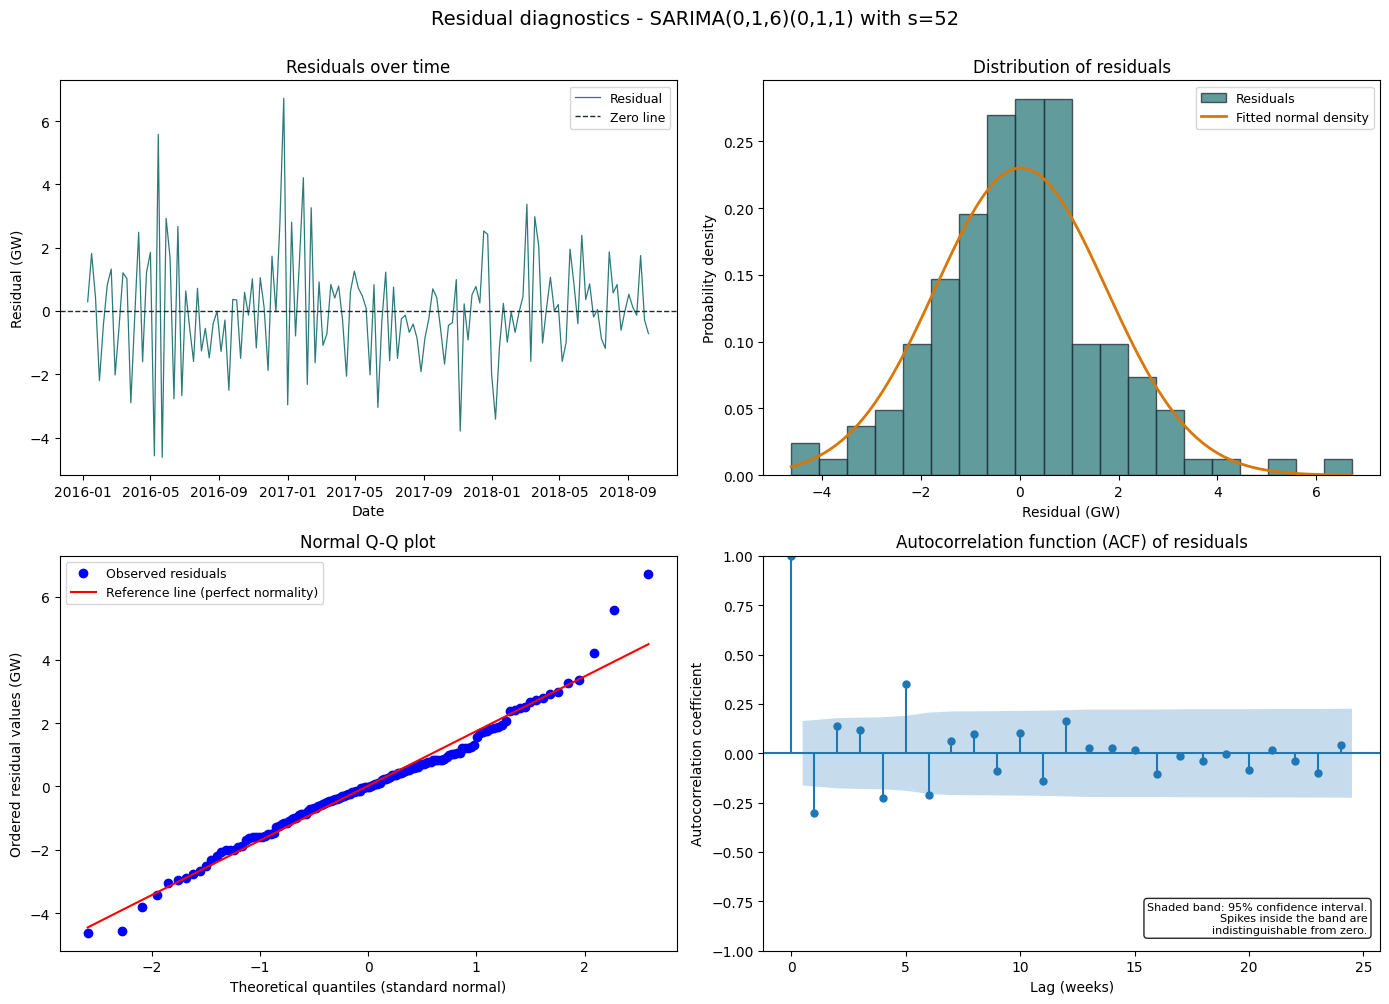

In [12]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# Drop observations consumed by regular and seasonal differencing
resid = sarima_fit.resid[53:]
print(f"Usable residuals: {len(resid)}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: residuals over time. Random scatter about zero indicates adequacy.
axes[0, 0].plot(resid.index, resid, lw=0.9, color="#2C7A7B", label="Residual")
axes[0, 0].axhline(0, color="#1F2933", lw=1, ls="--", label="Zero line")
axes[0, 0].set_title("Residuals over time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residual (GW)")
axes[0, 0].legend(loc="upper right", fontsize=9)

# Panel 2: histogram against a fitted normal density
axes[0, 1].hist(resid, bins=20, density=True, alpha=0.75,
                edgecolor="#1F2933", color="#2C7A7B", label="Residuals")
x = np.linspace(resid.min(), resid.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, resid.mean(), resid.std()),
                color="#D97706", lw=2, label="Fitted normal density")
axes[0, 1].set_title("Distribution of residuals")
axes[0, 1].set_xlabel("Residual (GW)")
axes[0, 1].set_ylabel("Probability density")
axes[0, 1].legend(loc="upper right", fontsize=9)

# Panel 3: Q-Q plot. Points on the line indicate normality.
stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q plot")
axes[1, 0].set_xlabel("Theoretical quantiles (standard normal)")
axes[1, 0].set_ylabel("Ordered residual values (GW)")
axes[1, 0].get_lines()[0].set_label("Observed residuals")
axes[1, 0].get_lines()[1].set_label("Reference line (perfect normality)")
axes[1, 0].legend(loc="upper left", fontsize=9)

# Panel 4: ACF of residuals. Spikes inside the band are indistinguishable from zero.
plot_acf(resid, lags=24, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("Autocorrelation function (ACF) of residuals")
axes[1, 1].set_xlabel("Lag (weeks)")
axes[1, 1].set_ylabel("Autocorrelation coefficient")
axes[1, 1].text(0.98, 0.04,
                "Shaded band: 95% confidence interval.\n"
                "Spikes inside the band are\nindistinguishable from zero.",
                transform=axes[1, 1].transAxes,
                ha="right", va="bottom", fontsize=8,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig.suptitle("Residual diagnostics - SARIMA(0,1,6)(0,1,1) with s=52",
             y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig("outputs/figures/03_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Formal test of residual autocorrelation

The Ljung-Box test examines whether residual autocorrelations, taken jointly across
a range of lags, differ significantly from zero. The null hypothesis is that the
residuals are independently distributed (white noise). A p-value below 0.05 rejects
this, indicating the model has left systematic structure unexplained.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_complex = acorr_ljungbox(resid, lags=[10, 20], return_df=True)

print("Ljung-Box test on AIC-selected model residuals")
print("(H0: no autocorrelation in residuals)\n")
print(lb_complex.round(4).to_string())

Ljung-Box test on AIC-selected model residuals
(H0: no autocorrelation in residuals)

    lb_stat  lb_pvalue
10  56.0931        0.0
20  66.9548        0.0


### Comparing residual adequacy

The AIC-selected model shows significant leftover autocorrelation. We now test
whether the parsimonious specification produces cleaner residuals, despite its
higher AIC.

In [14]:
resid_simple = sarima_simple.resid[53:]
lb_simple = acorr_ljungbox(resid_simple, lags=[10, 20], return_df=True)

print("Ljung-Box test on parsimonious model residuals\n")
print(lb_simple.round(4).to_string())

print("\nSummary comparison at lag 20:")
print(f"  SARIMA(0,1,6)(0,1,1,52): Q = {lb_complex.loc[20, 'lb_stat']:6.2f}, "
      f"p = {lb_complex.loc[20, 'lb_pvalue']:.4f}")
print(f"  SARIMA(0,1,1)(0,1,1,52): Q = {lb_simple.loc[20, 'lb_stat']:6.2f}, "
      f"p = {lb_simple.loc[20, 'lb_pvalue']:.4f}")

Ljung-Box test on parsimonious model residuals

    lb_stat  lb_pvalue
10  12.1604     0.2745
20  26.7116     0.1436

Summary comparison at lag 20:
  SARIMA(0,1,6)(0,1,1,52): Q =  66.95, p = 0.0000
  SARIMA(0,1,1)(0,1,1,52): Q =  26.71, p = 0.1436


### Interpreting the residual diagnostics

The two specifications reach opposite conclusions.

The AIC-selected model decisively fails the Ljung-Box test (Q(10) = 56.09,
p < 0.001; Q(20) = 66.95, p < 0.001), with visible ACF spikes at lags 1, 4, 5 and
6. Its six non-seasonal MA terms, nominally intended to model precisely this
short-run structure, are statistically unidentifiable. The specification is thus
simultaneously over-parameterised in its non-seasonal component and under-specified
in its short-run dynamics.

The parsimonious model passes the same test (Q(10) = 12.16, p = 0.275;
Q(20) = 26.71, p = 0.144). Its single non-seasonal MA term is estimated precisely
(coefficient -0.911, standard error 0.038), though its seasonal term loses
significance.

It is also worth noting that the statsmodels summary reports Ljung-Box (L1)
p = 0.90 for the AIC-selected model, apparently indicating adequacy. That
single-lag statistic is computed on the full residual series, including the 53
observations consumed by differencing, whose near-zero values dilute the test.
Testing jointly across lags on the cleaned residuals reverses the conclusion. This
illustrates the risk of relying on a single reported diagnostic without independent
verification.

In-sample criteria therefore disagree: AIC favours the six-term model, while
residual adequacy favours the parsimonious one. Out-of-sample accuracy provides the
decisive comparison.

## Forecasting the test period

We forecast the 104-week test period with both candidate specifications, including
95% confidence intervals as required by the brief.

In [15]:
from electricity_demand.models.sarimax import forecast_sarimax

h = len(test)

fc_complex, ci_complex = forecast_sarimax(sarima_fit,    h, test.index, alpha=0.05)
fc_simple,  ci_simple  = forecast_sarimax(sarima_simple, h, test.index, alpha=0.05)

print(f"Complex model first 3 forecasts (GW): {fc_complex.iloc[:3].round(2).tolist()}")
print(f"Simple  model first 3 forecasts (GW): {fc_simple.iloc[:3].round(2).tolist()}")
print(f"Actual  first 3 values          (GW): {test.iloc[:3].round(2).tolist()}")

Complex model first 3 forecasts (GW): [57.49, 57.94, 57.73]
Simple  model first 3 forecasts (GW): [58.01, 58.08, 58.36]
Actual  first 3 values          (GW): [55.85, 55.76, 58.68]


### Evaluating against the seasonal-naive benchmark

We compare both SARIMA specifications against the seasonal-naive benchmark from
Part 2 using MAE, RMSE, MASE, and Bias. MASE is the headline metric: it scales the
error by the in-sample seasonal-naive error, so lower values indicate better
performance relative to that baseline.

In [16]:
from electricity_demand.models.benchmarks import seasonal_naive_forecast
from electricity_demand.evaluation import evaluate_forecast

# Rebuild the seasonal-naive benchmark for a direct comparison
sn = seasonal_naive_forecast(train, h, 52, test.index)

results = pd.DataFrame([
    evaluate_forecast("seasonal_naive",          test, sn,         train),
    evaluate_forecast("SARIMA(0,1,6)(0,1,1,52)", test, fc_complex, train),
    evaluate_forecast("SARIMA(0,1,1)(0,1,1,52)", test, fc_simple,  train),
]).sort_values("MASE").reset_index(drop=True)

print("Forecast accuracy over the 104-week test period:\n")
print(results.round(3).to_string(index=False))

Forecast accuracy over the 104-week test period:

                  model   MAE  RMSE  MASE  Bias
         seasonal_naive 2.319 3.007 1.732 1.732
SARIMA(0,1,6)(0,1,1,52) 3.072 3.766 2.295 2.827
SARIMA(0,1,1)(0,1,1,52) 3.296 4.018 2.462 3.090


## SARIMA forecasts against actual demand

The plot shows both SARIMA forecasts with 95% confidence intervals, alongside the
seasonal-naive benchmark and the realised demand. The COVID-19 collapse from March
2020 is clearly visible and lies far outside the prediction intervals of every
model.

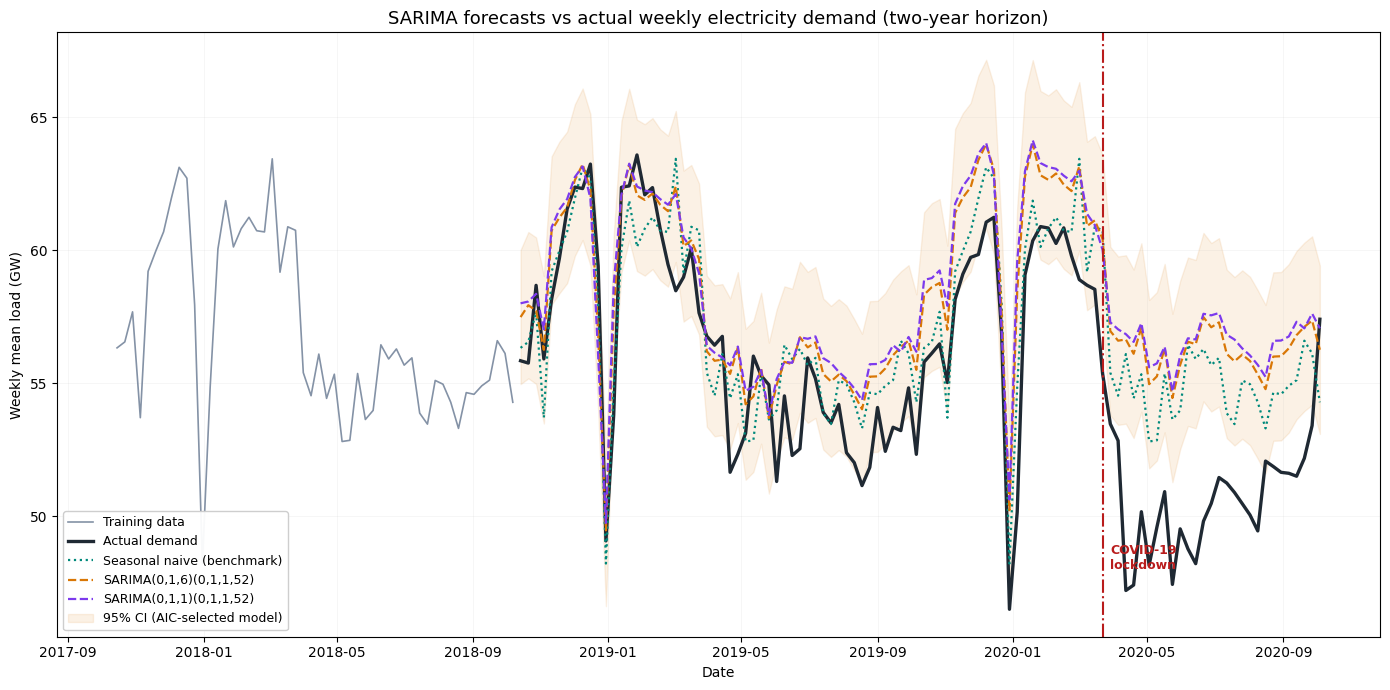

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

# Recent training context, muted so it recedes into the background
ax.plot(train.index[-52:], train.iloc[-52:],
        color="#8492A6", lw=1.2, label="Training data")

# Realised demand: the darkest, thickest line anchors the eye
ax.plot(test.index, test,
        color="#1F2933", lw=2.4, label="Actual demand")

# Benchmark from Part 2
ax.plot(test.index, sn,
        color="#00897B", lw=1.6, ls=":", label="Seasonal naive (benchmark)")

# The two SARIMA specifications
ax.plot(test.index, fc_complex,
        color="#D97706", lw=1.6, ls="--", label="SARIMA(0,1,6)(0,1,1,52)")
ax.plot(test.index, fc_simple,
        color="#7C3AED", lw=1.6, ls="--", label="SARIMA(0,1,1)(0,1,1,52)")

# 95% confidence interval for the AIC-selected model
ax.fill_between(test.index, ci_complex.iloc[:, 0], ci_complex.iloc[:, 1],
                color="#D97706", alpha=0.10, label="95% CI (AIC-selected model)")

# Onset of COVID-19 restrictions in Germany
ax.axvline(pd.Timestamp("2020-03-22", tz="UTC"), color="#B91C1C", ls="-.", lw=1.5)
ax.text(pd.Timestamp("2020-03-29", tz="UTC"), 48,
        "COVID-19\nlockdown", fontsize=9, color="#B91C1C", weight="bold")

ax.set_title("SARIMA forecasts vs actual weekly electricity demand (two-year horizon)",
             fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Weekly mean load (GW)")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.15, linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig("outputs/figures/03_sarima_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving the Part 3 outputs

We persist the forecasts, confidence intervals, and evaluation metrics so they can
be reused when comparing against the temperature-augmented, feature-based, and
neural models in later parts.

In [18]:
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

sarima_forecasts = pd.DataFrame({
    "actual":           test,
    "seasonal_naive":   sn,
    "sarima_complex":   fc_complex,
    "sarima_simple":    fc_simple,
    "complex_ci_lower": ci_complex.iloc[:, 0],
    "complex_ci_upper": ci_complex.iloc[:, 1],
})
sarima_forecasts.to_csv("outputs/forecasts/sarima_forecasts.csv")
results.to_csv("outputs/metrics/sarima_metrics.csv", index=False)

print("Saved SARIMA forecasts and metrics to outputs/")

Saved SARIMA forecasts and metrics to outputs/


## Part 3 conclusions

**Neither SARIMA specification improves on the seasonal-naive benchmark.** The
benchmark attains MASE 1.732 against 2.295 for the AIC-selected model and 2.462 for
the parsimonious one. This directly addresses the first analysis question of Part 7.

**Three criteria select three different models.** AIC favours SARIMA(0,1,6);
residual whiteness favours SARIMA(0,1,1); out-of-sample accuracy again favours
SARIMA(0,1,6), though it still loses to the naive benchmark. No single metric
adjudicates model quality on its own.

**All models are positively biased**, over-predicting by between 1.73 and 3.09 GW
on average. The cause is visible in the forecast plot: the COVID-19 lockdowns from
March 2020 collapsed demand to roughly 47 GW, a level absent from the 2015-2018
training period. Every model confidently forecast a normal year. The SARIMA models
are *more* biased than the benchmark because they additionally extrapolate the mild
upward trend observed before 2019, compounding the error.

**A structural break cannot be forecast from history alone.** This is the central
limitation of the analysis, and motivates the exogenous covariates introduced in
Part 4.